# Credit Risk Default System NorthBay Bank

## Data Cleaning and Preprocessing

Prepare the data for analysis by resolving quality issues, removing columns not available at credit assessment time, and defining a clean target variable.

### Steps Covered
* Inspect the dataset for missing values
* Handle missing values
* Drop post-origination and leaky columns
* Drop identifier and irrelevant columns
* Fix data types
* Filter loan status to fully resolved loans only
* Define the binary target variable
* Remove duplicates
* Visualizations
* Decision log

In [1]:
# Download the Lending Club dataset from Kaggle
import kagglehub

path = kagglehub.dataset_download("wordsforthewise/lending-club")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lending-club' dataset.
Path to dataset files: /kaggle/input/lending-club


In [2]:
# Load the accepted loans file into pandas
import pandas as pd
import os

df = pd.read_csv(
    os.path.join(path, "accepted_2007_to_2018Q4.csv.gz"),
    low_memory=False
)

# Preview the data
print(df.shape)
df.head()

(2260701, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## Inspect for Missing Values

**Goal:** Identify columns with missing values and decide what to do with each one.

**Strategy:**
- Columns with more than 50% missing values: Drop them entirely
- Columns with less than 50% missing: Fill them in
  - Numeric columns: fill with median
  - Categorical columns: fill with mode

In [3]:
# Check missing values across all columns
print("Missing values per column (sorted):")
print(df.isnull().sum().sort_values(ascending=False))

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Percentage of missing values per column
print("\nPercentage of missing values:")
print((df.isnull().mean()*100).sort_values(ascending=False).head(20))

Missing values per column (sorted):
member_id                                     2260701
orig_projected_additional_accrued_interest    2252050
hardship_reason                               2249784
hardship_payoff_balance_amount                2249784
hardship_last_payment_amount                  2249784
                                               ...   
total_rec_int                                      33
disbursement_method                                33
hardship_flag                                      33
debt_settlement_flag                               33
id                                                  0
Length: 151, dtype: int64

Total missing values: 108486252

Percentage of missing values:
member_id                                     100.000000
orig_projected_additional_accrued_interest     99.617331
hardship_reason                                99.517097
hardship_payoff_balance_amount                 99.517097
hardship_last_payment_amount                   99.51

## Handle Missing Values

**Step 1:** Drop columns with more than 50% missing values — too much data is gone to be useful

**Step 2:** Fill remaining missing values
- Numeric columns: median
- Categorical columns: mode

In [4]:
# Step1 - Drop columns with more than 50% missing values
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
high_missing_cols = missing_pct[missing_pct > 50].index.tolist()
df = df.drop(columns=high_missing_cols)
print(f"Dropped {len(high_missing_cols)} columns with more than 50% missing values:")
print(high_missing_cols)

# Step2 Fill remaining missing values
# Numeric columns with median
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Verify no missing values remain
print(f"\nTotal missing values after cleaning: {df.isnull().sum().sum()}")

Dropped 44 columns with more than 50% missing values:
['member_id', 'orig_projected_additional_accrued_interest', 'hardship_reason', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'payment_plan_start_date', 'hardship_type', 'hardship_status', 'hardship_start_date', 'deferral_term', 'hardship_amount', 'hardship_dpd', 'hardship_loan_status', 'hardship_length', 'hardship_end_date', 'settlement_status', 'debt_settlement_flag_date', 'settlement_term', 'settlement_percentage', 'settlement_date', 'settlement_amount', 'sec_app_mths_since_last_major_derog', 'sec_app_revol_util', 'revol_bal_joint', 'sec_app_inq_last_6mths', 'sec_app_num_rev_accts', 'sec_app_open_acc', 'sec_app_earliest_cr_line', 'sec_app_fico_range_high', 'sec_app_mort_acc', 'sec_app_open_act_il', 'sec_app_fico_range_low', 'sec_app_collections_12_mths_ex_med', 'sec_app_chargeoff_within_12_mths', 'verification_status_joint', 'dti_joint', 'annual_inc_joint', 'desc', 'mths_since_last_record', 'mths_since_recent_b

## Drop  Leaky Columns

**data leakage**
These are columns that would NOT be available at the time the bank makes a lending decision.
They only exist after a loan has already ended.

**Examples of leaky columns:**

- `recoveries`: money recovered after default (only known after default happens)
- `last_pymnt_amnt`: last payment amount (only known in the future)

**Decision:** Drop those columns

In [5]:
# These columns would not be available at the time of credit assessment
leakage_cols = [
    'funded_amnt', 'funded_amnt_inv', 'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',
    'hardship_flag', 'debt_settlement_flag',
    'collections_12_mths_ex_med', 'acc_now_delinq', 'delinq_amnt'
]

df = df.drop(columns=[c for c in leakage_cols if c in df.columns])
print(f"Shape after dropping leaky columns: {df.shape}")

Shape after dropping leaky columns: (2260701, 86)


## Drop Identifier and Irrelevant Columns

**Columns dropped:**
- `id`
- `url`
- `emp_title`
- `title`
- `zip_code`
- Constant columns: columns where every single row has the same value I dont think they can help the model learn anything

In [6]:
# Drop identifier and irrelevant columns
df = df.drop(columns=['id', 'url'])
df = df.drop(columns=['emp_title', 'title', 'zip_code'])

# Also drop constant columns
constant_cols = df.nunique()[df.nunique() <= 1].index.tolist()
df = df.drop(columns=constant_cols)
print(f"Dropped constant columns: {constant_cols}")

print(f"\nShape after dropping identifier columns: {df.shape}")

Dropped constant columns: ['policy_code']

Shape after dropping identifier columns: (2260701, 80)


## Fix Data Types

**Issues found:**
- `term` stored as "36 months" (text)
- `int_rate` stored as "13.56%" (text) )
- `emp_length` stored as "10+ years" (text)

convert them to number
- Date columns stored as text should be proper datetime format



In [7]:
# Fix data types

# term: "36 months" → 36
df['term'] = df['term'].str.replace(' months', '').astype(int)

# int_rate: "13.56%" → 13.56
if df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)

# emp_length: "10+ years" → 10, "< 1 year" → 0
df['emp_length'] = df['emp_length'].replace({
    '10+ years': '10',
    '< 1 year': '0',
    '1 year': '1'
})
df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').astype(float)

# dates: convert to datetime
date_cols = ['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%b-%Y')

# Verify fixes
print(df[['term', 'int_rate', 'emp_length']].dtypes)

term            int64
int_rate      float64
emp_length    float64
dtype: object


## Filter Loan Status to resolved loans only

**The problem:**
The `loan_status` column contains many different values, including loans that are still ongoing.
We don't know yet how those will end up because they could become Fully Paid or Charged Off.
so including them would confuse the model because we can't label them as 0 or 1.

We decide to drop `Late(16-30 days)`, `In Grace Period`, `Current`, `Does not meet credit policy`


In [8]:
# Filter loan status to fully resolved loans only
# let's check current distribution
print("Loan status before filtering:")
print(df['loan_status'].value_counts())

# Remove ambiguous statuses where final outcome is not yet known
remove_status = [
    'Current',
    'Late (16-30 days)',
    'In Grace Period',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
]

df = df[~df['loan_status'].isin(remove_status)]
print(f"\nShape after filtering: {df.shape}")
print("\nLoan status after filtering:")
print(df['loan_status'].value_counts())

Loan status before filtering:
loan_status
Fully Paid                                             1076784
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Shape after filtering: (1366850, 80)

Loan status after filtering:
loan_status
Fully Paid            1076784
Charged Off            268559
Late (31-120 days)      21467
Default                    40
Name: count, dtype: int64


## Define Binary Target Variable

**Column:** `loan_status`

**Mapping (from team meeting):**
- `1` = Default → Charged Off, Default, Late (31-120 days)
- `0` = Non-default → Fully Paid


In [9]:
# Define binary target variable
bad_status = ['Charged Off', 'Default', 'Late (31-120 days)']
df['loan_status'] = df['loan_status'].apply(lambda x: 1 if x in bad_status else 0)

# check
print("Target variable distribution:")
print(df['loan_status'].value_counts())

total = len(df)
defaults = df['loan_status'].sum()
print(f"\nDefault rate: {defaults/total*100:.1f}%")
print(f"Non-default rate: {(total-defaults)/total*100:.1f}%")

Target variable distribution:
loan_status
0    1076784
1     290066
Name: count, dtype: int64

Default rate: 21.2%
Non-default rate: 78.8%


## Remove Duplicate Rows



In [10]:
# Point 8 - Check and remove duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 32
Shape after removing duplicates: (1366818, 80)


## Visualizations

Exploring the data visually to understand distributions, class imbalance, outliers, and relationships between features.

### Plot 1 Class Imbalance

Check how balanced our target variable is between defaulters and non-defaulters.


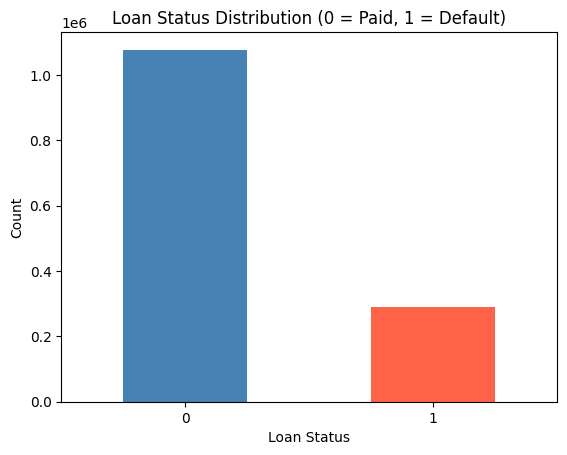

Class distribution:
loan_status
0    78.778008
1    21.221992
Name: proportion, dtype: float64


In [11]:
# Class imbalance
import matplotlib.pyplot as plt
import seaborn as sns

df['loan_status'].value_counts().plot(kind='bar',
                                       color=['steelblue', 'tomato'],
                                       title='Loan Status Distribution (0 = Paid, 1 = Default)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Print percentages
print("Class distribution:")
print(df['loan_status'].value_counts(normalize=True) * 100)

### Outlier Detection

We use the IQRmethod to identify outliers in numeric columns.


helps us understand which columns have extreme values that could affect model performance.

In [12]:
# Detect outliers using IQR method
num_cols = df.select_dtypes(include='number').columns.tolist()

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_df = pd.Series(outlier_summary).sort_values(ascending=False)
print("Outlier counts per column (top 20):")
print(outlier_df.head(20))

Outlier counts per column (top 20):
total_bal_il             557510
max_bal_bc               557461
all_util                 547180
mths_since_rcnt_il       521781
il_util                  472914
open_rv_24m              452059
inq_last_12m             427577
open_act_il              421098
inq_fi                   419589
open_rv_12m              391685
open_il_24m              388628
open_acc_6m              380152
term                     333575
num_accts_ever_120_pd    308200
loan_status              290066
open_il_12m              280037
total_cu_tl              266853
delinq_2yrs              263794
pub_rec                  231922
tot_coll_amt             199496
dtype: int64


### Boxplots for Top 10 Outlier Columns


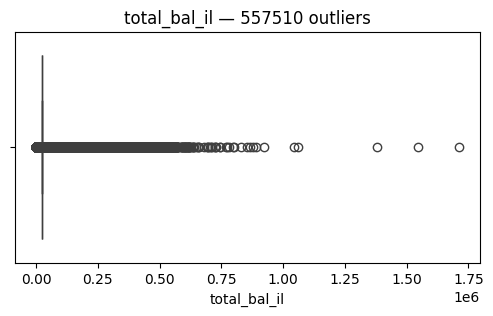

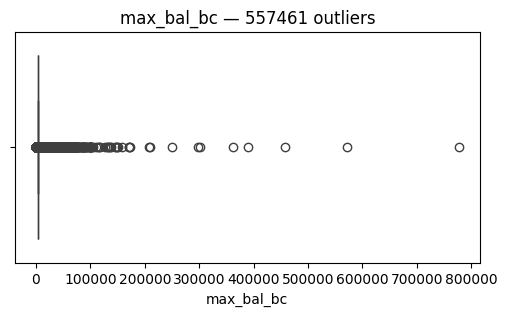

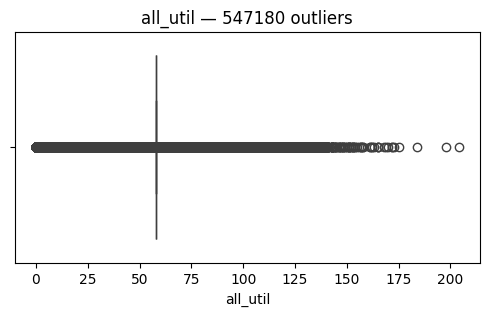

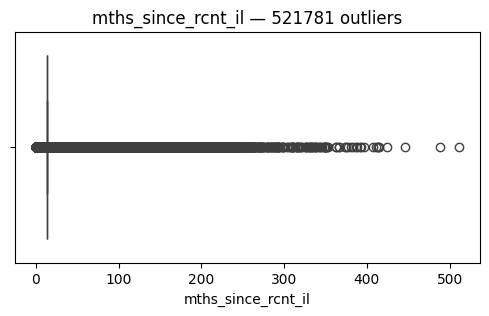

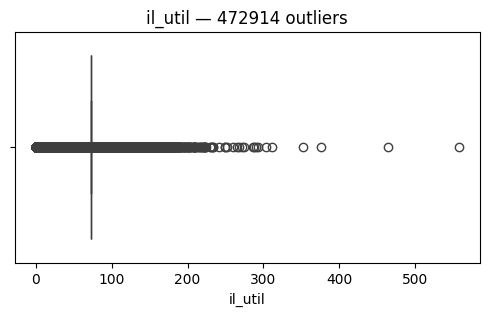

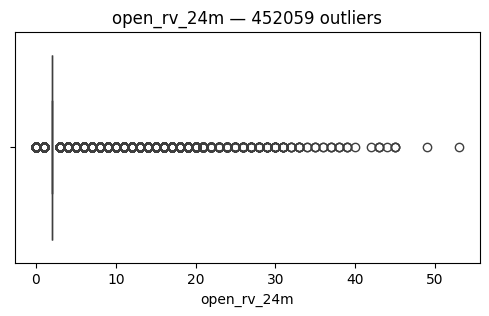

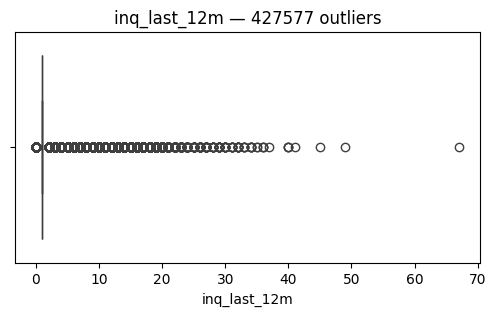

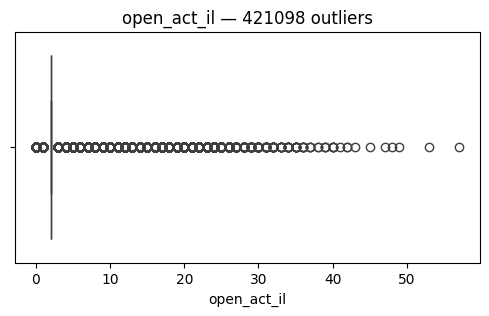

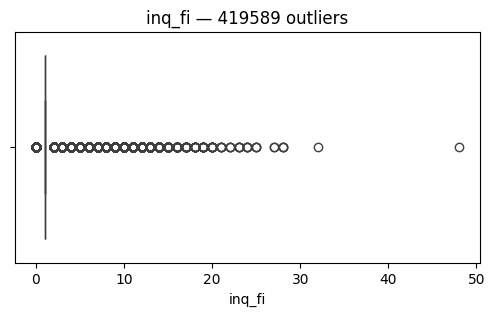

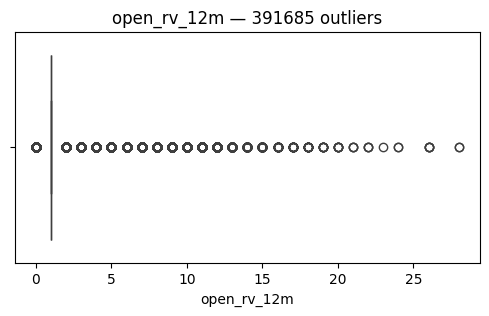

In [13]:
# Boxplots for top 10 outlier columns
skip_cols = ['loan_status', 'term']
top_outlier_cols = [col for col in outlier_df.head(12).index.tolist()
                    if col not in skip_cols][:10]

for col in top_outlier_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"{col} — {outlier_summary[col]} outliers")
    plt.show()

### Monetary Columns


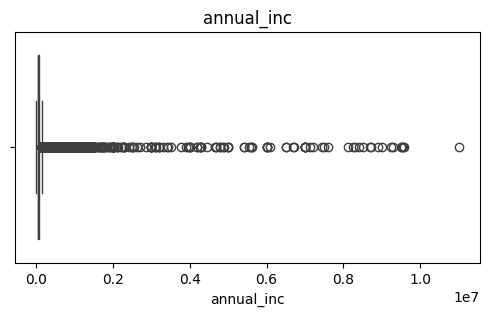

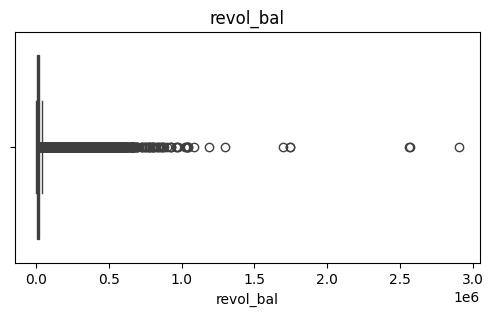

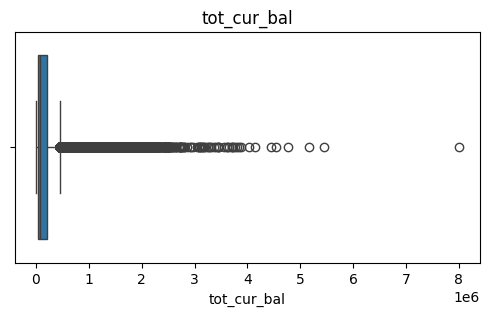

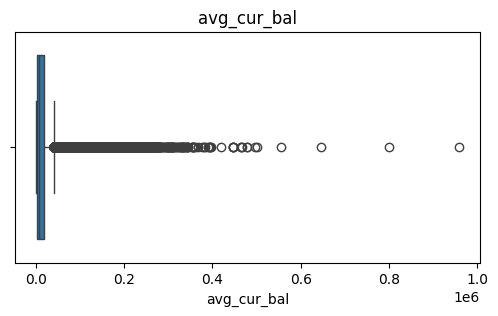

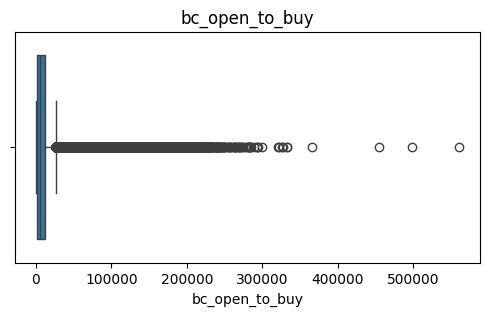

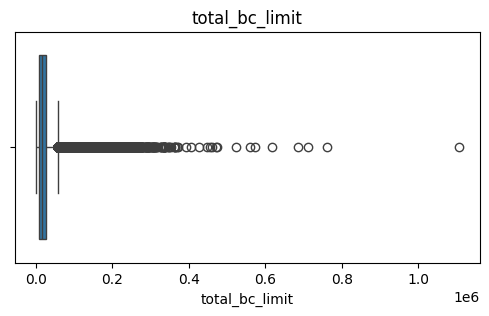

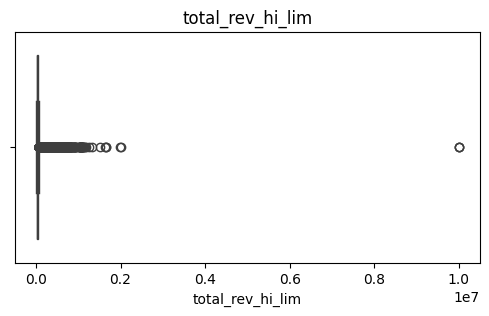

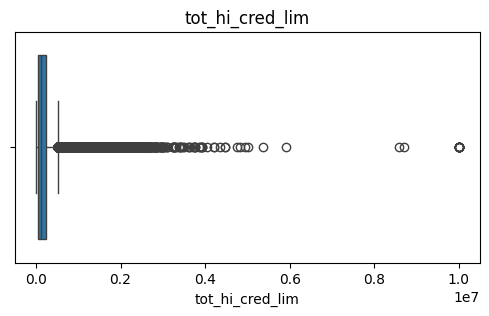

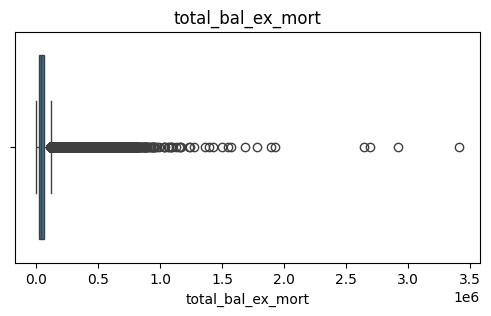

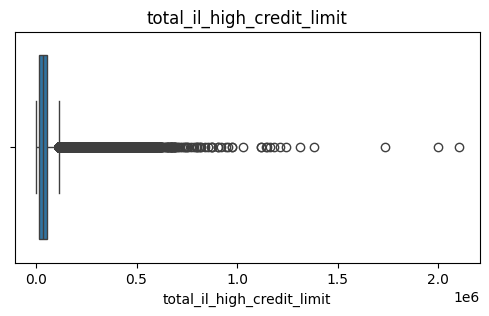

99th percentile vs max for monetary columns:
annual_inc: 99th pct = 251000, max = 10999200
revol_bal: 99th pct = 94413, max = 2904836
tot_cur_bal: 99th pct = 665387, max = 8000078
avg_cur_bal: 99th pct = 72381, max = 958084
bc_open_to_buy: 99th pct = 73084, max = 559912
total_bc_limit: 99th pct = 102700, max = 1105500
total_rev_hi_lim: 99th pct = 154100, max = 9999999
tot_hi_cred_lim: 99th pct = 756793, max = 9999999
total_bal_ex_mort: 99th pct = 232188, max = 3408095
total_il_high_credit_limit: 99th pct = 201299, max = 2101913


In [14]:
# monetary columns
monetary_cols = ['annual_inc', 'revol_bal', 'tot_cur_bal', 'avg_cur_bal',
                 'bc_open_to_buy', 'total_bc_limit', 'total_rev_hi_lim',
                 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_il_high_credit_limit']

# Only plot columns that exist in our dataframe
monetary_cols = [col for col in monetary_cols if col in df.columns]

for col in monetary_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Check 99th percentile vs max
print("99th percentile vs max for monetary columns:")
for col in monetary_cols:
    print(f"{col}: 99th pct = {df[col].quantile(0.99):.0f}, max = {df[col].max():.0f}")

### Distribution of Key Numeric Features



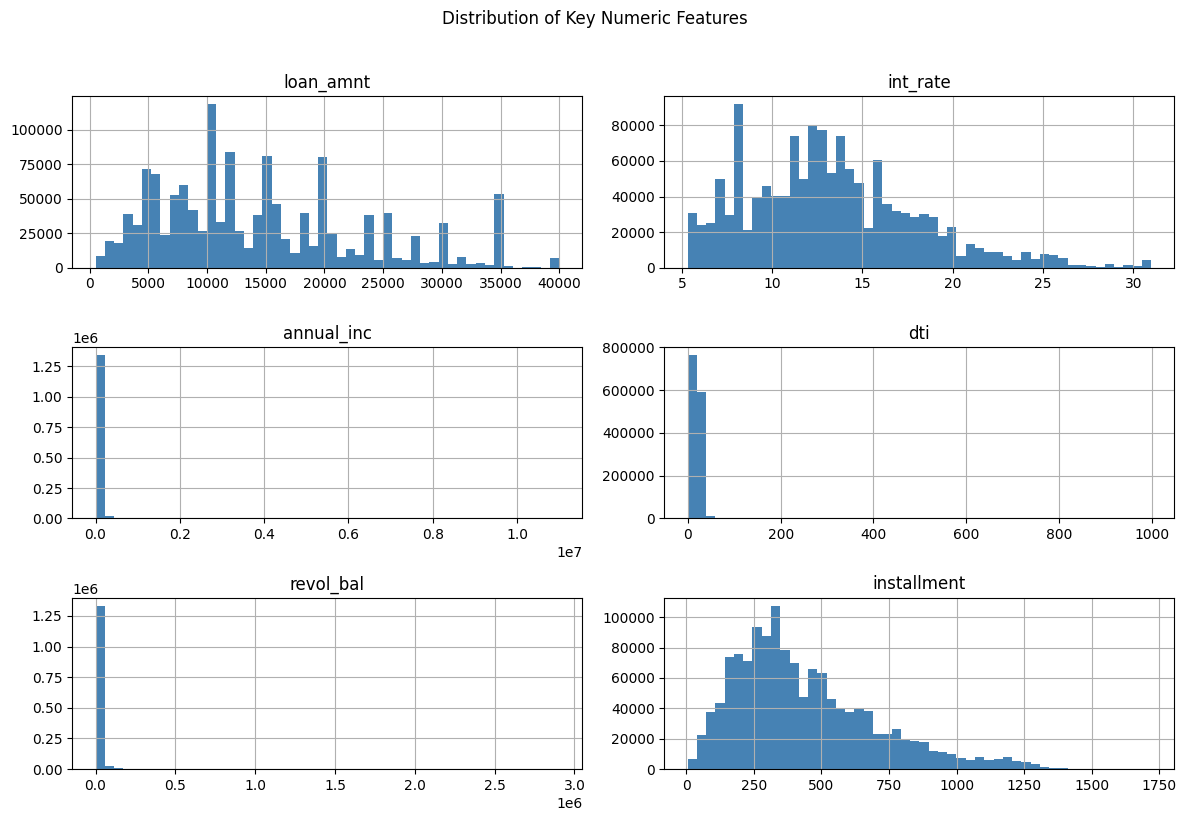

In [15]:
# Distribution of key numeric features
num_cols_to_plot = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_bal', 'installment']
num_cols_to_plot = [col for col in num_cols_to_plot if col in df.columns]

df[num_cols_to_plot].hist(figsize=(12, 8), bins=50, color='steelblue')
plt.suptitle('Distribution of Key Numeric Features', y=1.02)
plt.tight_layout()
plt.show()

### Correlation Heatmap

Shows how strongly numeric features are related to each other.

- **Dark red** = strong positive correlation (both go up together)
- **Dark blue** = strong negative correlation (one goes up, the other goes down)
- **White / light** = little or no relationship


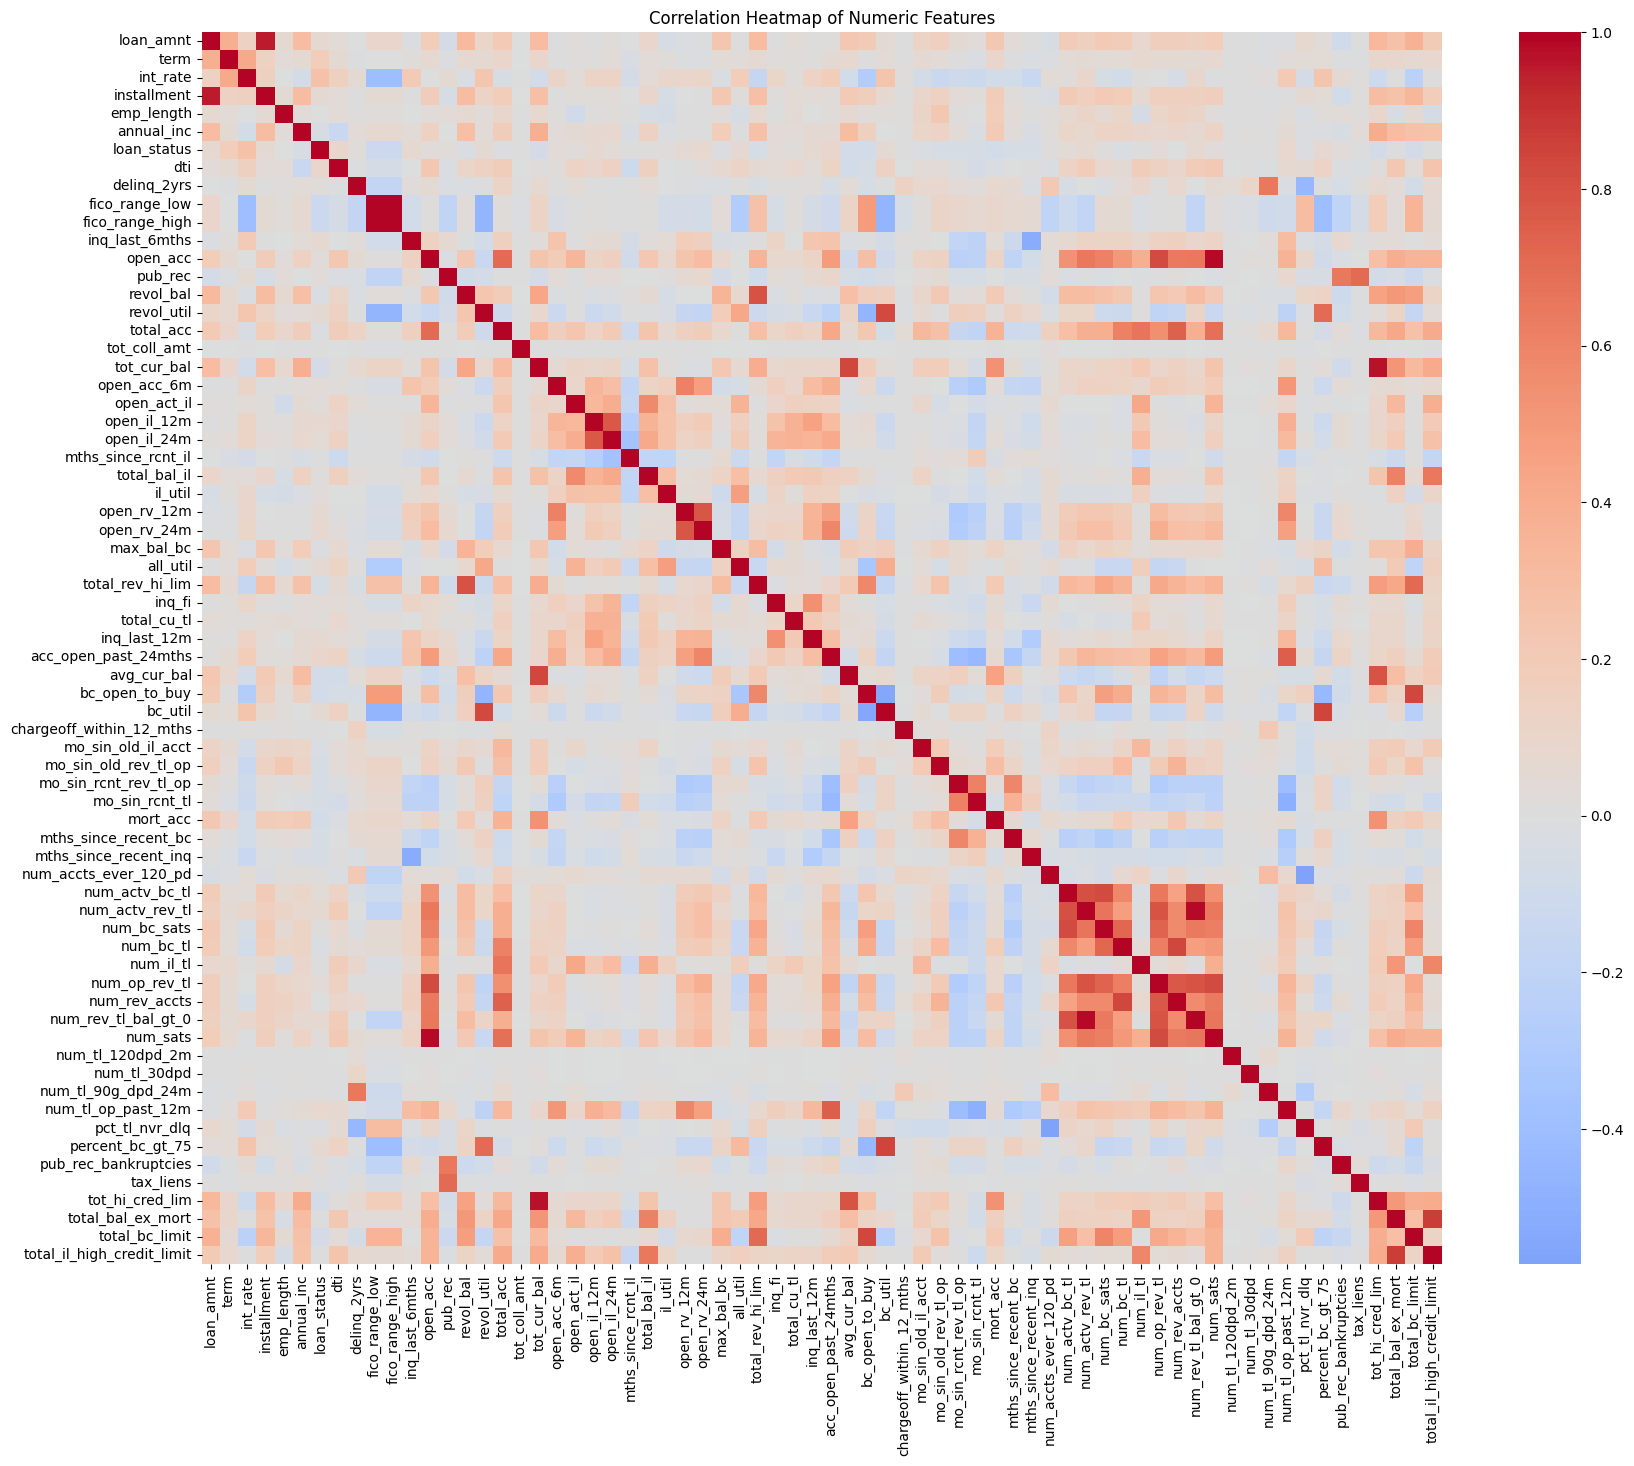

In [16]:
# Plot 6 - Correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    cmap='coolwarm',
    center=0,
    annot=False
)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [17]:
# Final state of the dataset after all cleaning steps
print("=== FINAL DATASET SUMMARY ===")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"\nTarget variable distribution:")
print(df['loan_status'].value_counts())
print(f"\nDefault rate: {df['loan_status'].mean()*100:.1f}%")

=== FINAL DATASET SUMMARY ===
Shape: (1366818, 80)
Missing values: 0
Duplicates: 0

Target variable distribution:
loan_status
0    1076752
1     290066
Name: count, dtype: int64

Default rate: 21.2%


## Data Preparation

With the data cleaned and explored, we now prepare it for modeling.
This involves selecting features, engineering new ones, splitting the data,
scaling numeric features, and encoding categorical variables.

In [18]:
# Feature selection
# Drop columns that do not contribute meaningful signal to the model


cols_to_drop = ['sub_grade', 'issue_d']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

df = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} low-signal columns: {cols_to_drop}")
print(f"Shape after feature selection: {df.shape}")

Dropped 2 low-signal columns: ['sub_grade', 'issue_d']
Shape after feature selection: (1366818, 78)


In [19]:
# Feature engineering
# Create new features from existing columns that may carry stronger signal

# 1. loan_to_income: how large is the loan relative to the borrower's income?
# A bigger ratio means the borrower is taking on more risk relative to what they earn
if 'loan_amnt' in df.columns and 'annual_inc' in df.columns:
    df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)

# 2. installment_to_income: what percentage of monthly income goes to the loan payment?
# High values mean the borrower is stretched thin every month
if 'installment' in df.columns and 'annual_inc' in df.columns:
    df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)

# 3. credit_utilization_gap: difference between revolving limit and revolving balance
# A small gap means the borrower is close to maxing out their credit
if 'total_rev_hi_lim' in df.columns and 'revol_bal' in df.columns:
    df['credit_utilization_gap'] = df['total_rev_hi_lim'] - df['revol_bal']

print("New features created:")
new_features = ['loan_to_income', 'installment_to_income', 'credit_utilization_gap']
new_features = [col for col in new_features if col in df.columns]
print(df[new_features].describe())

New features created:
       loan_to_income  installment_to_income  credit_utilization_gap
count    1.366818e+06           1.366818e+06            1.366818e+06
mean     5.215809e+00           2.298378e-01            1.617091e+04
std      3.444831e+02           1.020427e+01            2.224666e+04
min      1.714285e-04           6.911988e-05           -1.446830e+05
25%      1.249969e-01           4.636443e-02            4.800000e+03
50%      1.999958e-01           7.227820e-02            1.060200e+04
75%      2.916634e-01           1.055761e-01            2.070900e+04
max      4.000000e+04           1.466850e+03            7.439296e+06


In [20]:
# Separate features and target variable

X = df.drop(columns=['loan_status'])
y = df['loan_status']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features (X) shape: (1366818, 80)
Target (y) shape: (1366818,)

Target distribution:
loan_status
0    1076752
1     290066
Name: count, dtype: int64


In [21]:
# Train/test split
# We split the data into 2 partsbefore scaling
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% training, 20% testing
    random_state=42,      # fixed seed so results are reproducible
    stratify=y            # keep the same default rate in both splits
)

print(f"Training set:  {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:      {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nDefault rate in training set: {y_train.mean()*100:.1f}%")
print(f"Default rate in test set:     {y_test.mean()*100:.1f}%")

Training set:  1,093,454 rows (80%)
Test set:      273,364 rows (20%)

Default rate in training set: 21.2%
Default rate in test set:     21.2%


In [22]:
# We use Log to transform highly skewed numeric columns
import numpy as np

# Define numeric_cols
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()

skewed_cols = ['annual_inc', 'revol_bal', 'loan_to_income',
               'installment_to_income', 'credit_utilization_gap']

skewed_cols = [col for col in skewed_cols if col in numeric_cols]

for col in skewed_cols:

    X_train[col] = np.log1p(X_train[col].apply(lambda x: max(0, x)))
    X_test[col] = np.log1p(X_test[col].apply(lambda x: max(0, x)))

print(f"Applied log1p transformation to {len(skewed_cols)} columns:")
print(skewed_cols)

Applied log1p transformation to 5 columns:
['annual_inc', 'revol_bal', 'loan_to_income', 'installment_to_income', 'credit_utilization_gap']


Some columns have few extreme values like annual_inc (some people earn $10M) that can confuse the model so we used log to make the distribution more balanced and it only to numeric columns that are highly skewed

In [23]:
# Scale numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling complete.")
print(f"\nSample of scaled training data (first 3 rows, first 5 numeric columns):")
print(X_train[numeric_cols[:5]].head(3))

Scaling complete.

Sample of scaled training data (first 3 rows, first 5 numeric columns):
         loan_amnt      term  int_rate  installment  emp_length
1844194  -0.109902  1.760852  2.020679    -0.224903    0.216613
212893   -1.082673 -0.567907  0.149072    -1.023708    0.486418
1754206  -0.544788 -0.567907 -1.123036    -0.517490   -0.862606


Scaling brings everything to the same range

We fit the scaler ONLY on training data, then apply it to both train and test.

In [24]:
# Encode categorical variables
# convert text categories into numeric columns

categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns -test set may be missing some categories that appeared in training

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"Shape after encoding:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

Shape after encoding:
  X_train: (1093454, 151)
  X_test:  (273364, 151)


In [25]:
# Final verification before modeling

print("=== FINAL DATA PREPARATION SUMMARY ===")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nMissing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test:  {X_test.isnull().sum().sum()}")
print(f"\nDefault rate in y_train: {y_train.mean()*100:.1f}%")
print(f"Default rate in y_test:  {y_test.mean()*100:.1f}%")
print(f"\nTotal features going into the model: {X_train.shape[1]}")

=== FINAL DATA PREPARATION SUMMARY ===

X_train shape: (1093454, 151)
X_test shape:  (273364, 151)
y_train shape: (1093454,)
y_test shape:  (273364,)

Missing values in X_train: 0
Missing values in X_test:  0

Default rate in y_train: 21.2%
Default rate in y_test:  21.2%

Total features going into the model: 151
